In [1]:
!pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00


In [7]:
!pip install qiskit-aer pylatexenc

**VISUALIZATION**

In [1]:
from qiskit import QuantumCircuit

Two ways to represents the Circuit object:


*   QuantumCircuit.Draw() => Returns the diagrams. No side effects
*   print(QuantumCircuit) => Returns None. Diagram is the side effect

But in Jupyter Notebook both displays the idential "ASCII circuit diagram" as the output by default.



In [25]:
# Building a quantum circuit
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.h(range(3))
qc.cx(0, 1)
qc.barrier()
qc.measure(range(3), range(3))

In [26]:
qc.draw() # 1st method

┌───┐┌───┐      ░ ┌─┐      
q_0: ┤ X ├┤ H ├──■───░─┤M├──────
     ├───┤└───┘┌─┴─┐ ░ └╥┘┌─┐   
q_1: ┤ H ├─────┤ X ├─░──╫─┤M├───
     ├───┤     └───┘ ░  ║ └╥┘┌─┐
q_2: ┤ H ├───────────░──╫──╫─┤M├
     └───┘           ░  ║  ║ └╥┘
c: 3/═══════════════════╩══╩══╩═
                        0  1  2

In [27]:
print(qc) # 2nd method

     ┌───┐┌───┐      ░ ┌─┐      
q_0: ┤ X ├┤ H ├──■───░─┤M├──────
     ├───┤└───┘┌─┴─┐ ░ └╥┘┌─┐   
q_1: ┤ H ├─────┤ X ├─░──╫─┤M├───
     ├───┤     └───┘ ░  ║ └╥┘┌─┐
q_2: ┤ H ├───────────░──╫──╫─┤M├
     └───┘           ░  ║  ║ └╥┘
c: 3/═══════════════════╩══╩══╩═
                        0  1  2 


QuantumCircuit.draw() by default and print() don't provide much flexibility.<br>
So, two other alternatives are used for better flexibility:


*   Matplotlib => QuantumCircuit.draw(output="mpl")
*   Latex => QuantumCircuit.draw(output="latex")



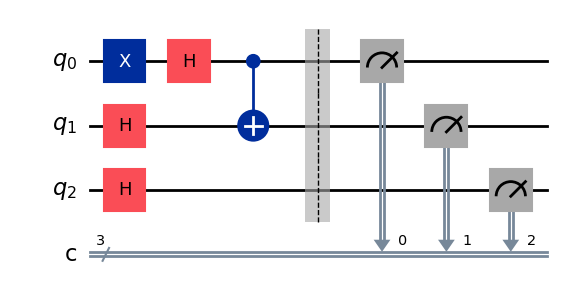

In [28]:
qc.draw(output="mpl")

In [29]:
qc.draw(output="latex") # We need to do many installations to get this working

MissingOptionalLibraryError: "The 'pdftocairo' library is required to use 'LaTeX circuit drawing'.  This is part of the 'poppler' set of PDF utilities."

To **save** the circuit diagrams in a file, add "filename" attribute to the draw() function

In [30]:
qc.draw(filename="circuit.pdf")

┌───┐┌───┐      ░ ┌─┐      
q_0: ┤ X ├┤ H ├──■───░─┤M├──────
     ├───┤└───┘┌─┴─┐ ░ └╥┘┌─┐   
q_1: ┤ H ├─────┤ X ├─░──╫─┤M├───
     ├───┤     └───┘ ░  ║ └╥┘┌─┐
q_2: ┤ H ├───────────░──╫──╫─┤M├
     └───┘           ░  ║  ║ └╥┘
c: 3/═══════════════════╩══╩══╩═
                        0  1  2

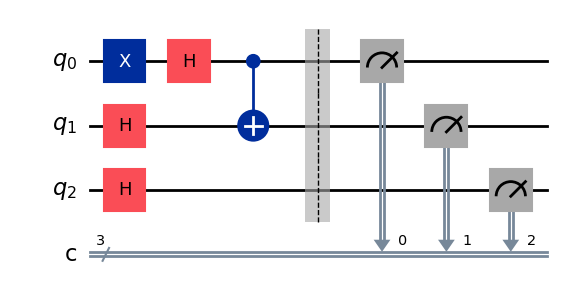

In [31]:
qc.draw(output="mpl", filename="circuit.jpeg")

In [32]:
qc.draw(output="latex", filename="circuit.jpeg")

MissingOptionalLibraryError: "The 'pdftocairo' library is required to use 'LaTeX circuit drawing'.  This is part of the 'poppler' set of PDF utilities."

The draw() methods returns the image of the object in which class:

*   text (default) => TextDrawer Object
*   mpl => matplotlib.Figure
*   latex => PIL.Image



Another kwarg "**interactive**" can be used to display the image in a new window. It is a boolean kwarg.

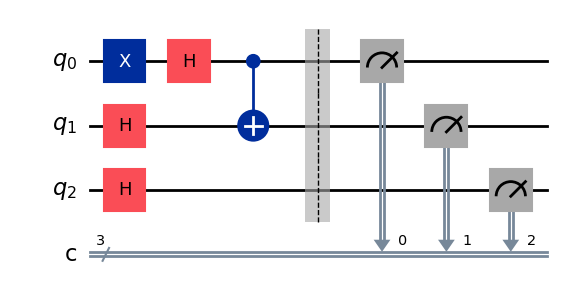

In [33]:
qc.draw(output = "mpl", interactive = True)

Next, there is a kwarg used to reverse the order of bits shown in the image namely, "**reverse_bits**"

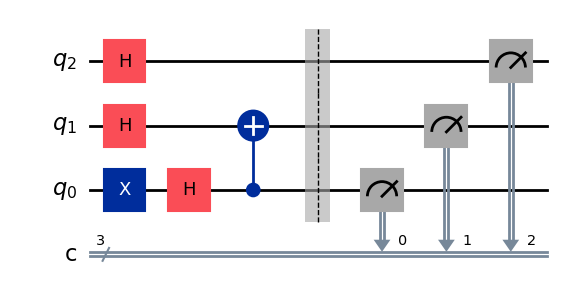

In [34]:
qc.draw(output="mpl", reverse_bits=True)

There is a kwarg in the draw() function to decide whether to display the barrier in the images named "**plot_barriers**"

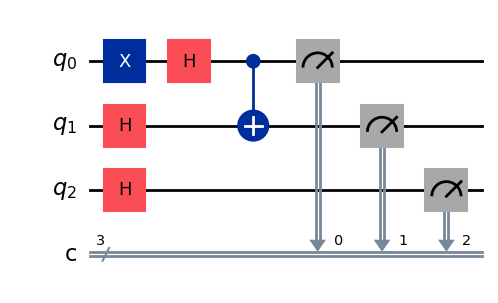

In [35]:
qc.draw(output="mpl", plot_barriers=False)

To change colors and outlines of the 'mpl' renderer, **"Style"** kwarg can be used. For more details for this kwarg, refer https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#draw

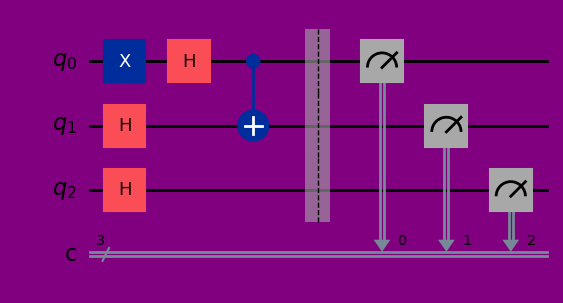

In [38]:
style = {"backgroundcolor": "purple"}
qc.draw(output="mpl", style=style)

To set the maximum width of the output in the Text(default) renderer and after that, the circuit is split and remaining is displayed below in the next line using a kwarg called **"fold"**

In [42]:
qc.draw(fold=20)

┌───┐┌───┐»
q_0: ┤ X ├┤ H ├»
     ├───┤└───┘»
q_1: ┤ H ├─────»
     ├───┤     »
q_2: ┤ H ├─────»
     └───┘     »
c: 3/══════════»
               »
«           ░ ┌─┐»
«q_0: ──■───░─┤M├»
«     ┌─┴─┐ ░ └╥┘»
«q_1: ┤ X ├─░──╫─»
«     └───┘ ░  ║ »
«q_2: ──────░──╫─»
«           ░  ║ »
«c: 3/═════════╩═»
«              0 »
«           
«q_0: ──────
«     ┌─┐   
«q_1: ┤M├───
«     └╥┘┌─┐
«q_2: ─╫─┤M├
«      ║ └╥┘
«c: 3/═╩══╩═
«      1  2

The **"scale"** kwarg scales the output in 'mpl' and 'latex' renderer

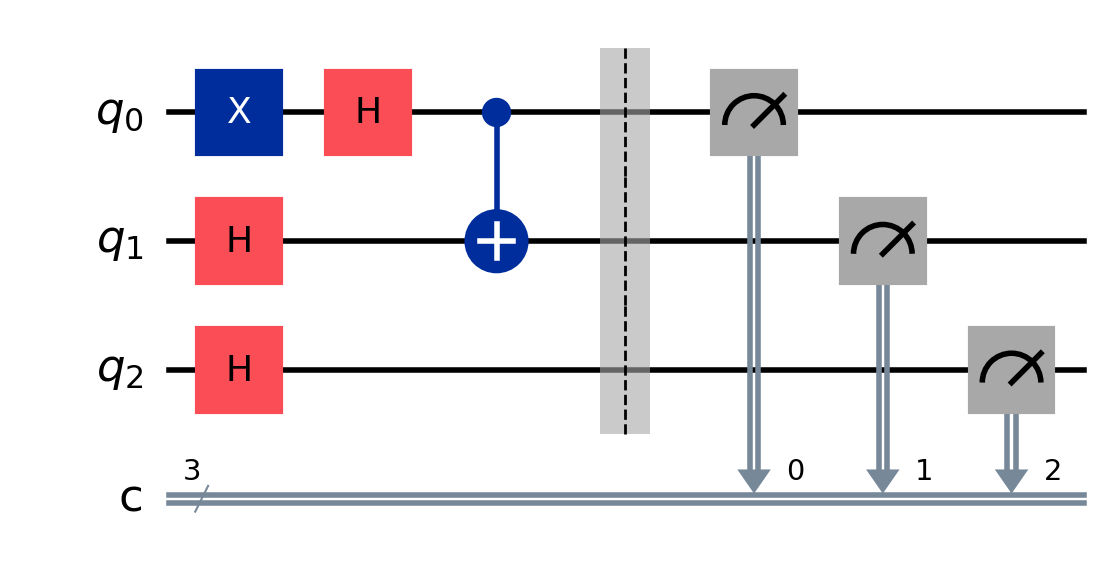

In [44]:
qc.draw(output='mpl', scale=2)

⏩**Summary of QuantumCircuit.draw() function:**


1.   output => 'text' (default), 'mpl' (Matplotlib), 'latex' (LaTex)
2.   filename => To save the image in a file. Applicable to all three renderers
3.   interactive => To open the image in a new window. Applicable to all three renderers
4.   reverse_bits => To reverse the bits in the image. Applicable to all three renderers
5.   plot_barriers => To decide to plot ot not the barriers in the image. Applicable to all three renderers
6.   style => To style the circuit output. Applicable only to 'mpl'
7.   fold => To limit the width of the output. Applicable only to 'text'
8.   scale => To scale the output. Applicable to both'mpl' and 'latex'


**circuit_drawer()**

QuantumCircuit.draw() is a function/method of QuantumCircuit Object.<br>
circuit_drawer() is a self contained function that is identical to QuantumCircuit.draw()<br>
circuit_drawer() is imported from qiskit.visualization and the circuit is passed as an argument

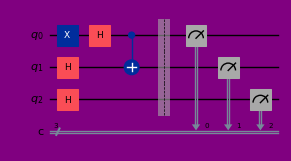

In [46]:
from qiskit.visualization import circuit_drawer
circuit_drawer(qc, output='mpl', style=style, scale=0.5)